In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
     

In [2]:
df = pd.read_csv('movies_metadata.csv')

In [3]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,FALSE,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,30-10-1995,373554033,81,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,FALSE,7.7,5415
1,FALSE,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,15-12-1995,262797249,104,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,FALSE,6.9,2413
2,FALSE,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,22-12-1995,0,101,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,FALSE,6.5,92
3,FALSE,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,22-12-1995,81452156,127,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,FALSE,6.1,34
4,FALSE,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,10-02-1995,76578911,106,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,FALSE,5.7,173


In [4]:
df.isnull().sum()

adult                        0
belongs_to_collection    40981
budget                      16
genres                      23
homepage                 37715
id                          31
imdb_id                     48
original_language           42
original_title              32
overview                   987
popularity                 123
poster_path                499
production_companies       120
production_countries       117
release_date               196
revenue                    133
runtime                    403
spoken_languages           161
status                     254
tagline                  25108
title                      239
video                      185
vote_average               183
vote_count                 184
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(17)

In [6]:
df = df.drop_duplicates().reset_index(drop=True)  # Droping Duplicated values

In [7]:
df = df[['title', 'overview', 'genres', 'tagline', 'vote_average', 'popularity']]

In [8]:
df.head()

,title,overview,genres,tagline,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",NaN,7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",Roll the dice and unleash the excitement!,6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",Friends are the people who let you be yourself...,6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]",Just When His World Is Back To Normal... He's ...,5.7,8.387519


In [9]:
# Seeing the DataType of [['vote_average', 'popularity']]

print(df[['vote_average', 'popularity']].dtypes)

vote_average    object
popularity      object
dtype: object


In [10]:
# The [['vote_average', 'popularity']] is in "Object" i.e "String" so we are converting them into numerics 

df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')  # coerce means: “Convert invalid values into NaN (missing values)”  

df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

In [11]:
df.isnull().sum()

title             239
overview          987
genres             23
tagline         25096
vote_average      317
popularity        292
dtype: int64

In [12]:
df = df.dropna(subset=['title'])

In [13]:
df = df.dropna(subset=['genres'])

In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 45316 entries, 0 to 45554
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         45316 non-null  object 
 1   overview      44362 non-null  object 
 2   genres        45316 non-null  object 
 3   tagline       20396 non-null  object 
 4   vote_average  45238 non-null  float64
 5   popularity    45248 non-null  float64
dtypes: float64(2), object(4)
memory usage: 2.4+ MB


In [15]:
df.describe()

,vote_average,popularity
count,45238.000000,45248.000000
mean,5.618622,2.925515
std,1.922969,6.015916
min,0.000000,0.000000
25%,5.000000,0.386467
50%,6.000000,1.129180
75%,6.800000,3.687595
max,10.000000,547.488298


In [16]:
print(df[['vote_average', 'popularity']].dtypes)

vote_average    float64
popularity      float64
dtype: object


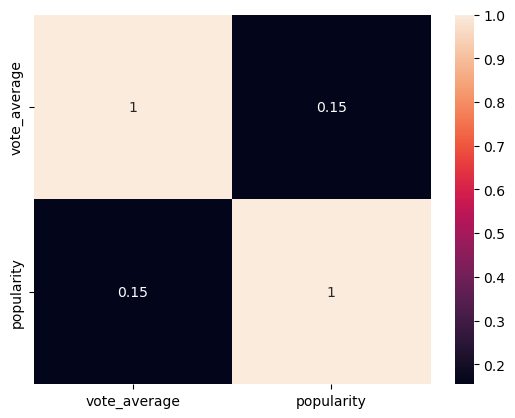

In [17]:
corr = df[['vote_average', 'popularity']].corr()

sns.heatmap(corr, annot=True)
plt.show()

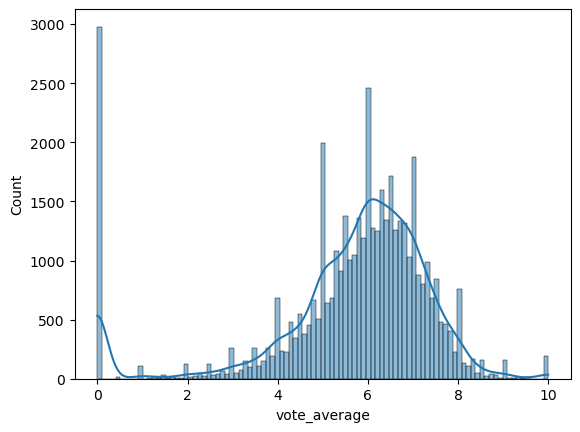

In [18]:
sns.histplot(df['vote_average'], kde=True)  # kde = stands for Kernel Density Estimation
plt.show()                                # It adds a smooth curve over your histogram

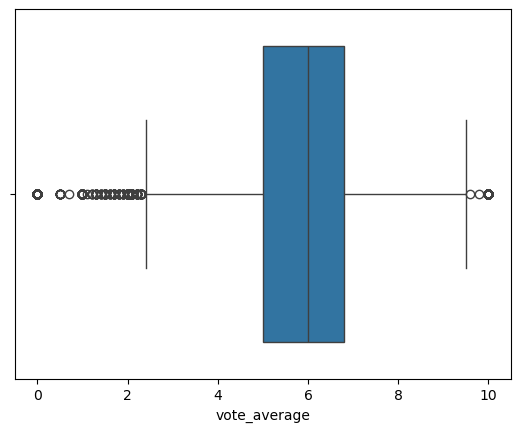

In [19]:
sns.boxplot(x=df['vote_average'])
plt.show()

In [20]:
# Show: Top popular movies, Highest rated movies

df.sort_values(by='popularity', ascending=False).head(10)

,title,overview,genres,tagline,vote_average,popularity
30757,Minions,"Minions Stuart, Kevin and Bob are recruited by...","[{'id': 10751, 'name': 'Family'}, {'id': 16, '...","Before Gru, they had a history of bad bosses",6.4,547.488298
33425,Wonder Woman,An Amazon princess comes to the world of Man t...,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",Power. Grace. Wisdom. Wonder.,7.2,294.337037
42303,Beauty and the Beast,A live-action adaptation of Disney's version o...,"[{'id': 10751, 'name': 'Family'}, {'id': 14, '...",Be our guest.,6.8,287.253654
43727,Baby Driver,After being coerced into working for a crime b...,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",All you need is one killer track.,7.2,228.032744
24496,Big Hero 6,The special bond that develops between plus-si...,"[{'id': 12, 'name': 'Adventure'}, {'id': 10751...",From the creators of Wreck-it Ralph and Frozen,7.8,213.849907
26613,Deadpool,Deadpool tells the origin story of former Spec...,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",Witness the beginning of a happy ending,7.4,187.860492
26615,Guardians of the Galaxy Vol. 2,The Guardians must fight to keep their newfoun...,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",Obviously.,7.6,185.330992
14567,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",Enter the World of Pandora.,7.2,185.070892
24392,John Wick,Ex-lunatic John Wick comes off his meds to tra...,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",Don't set him off.,7.0,183.870374
23704,Gone Girl,With his wife's disappearance having become th...,"[{'id': 9648, 'name': 'Mystery'}, {'id': 53, '...",You don't know what you've got 'til it's...,7.9,154.801009


In [21]:
df.isnull().sum()

title               0
overview          954
genres              0
tagline         24920
vote_average       78
popularity         68
dtype: int64

In [22]:
df['overview'] = df['overview'].fillna('')  

<Axes: xlabel='overview_length', ylabel='Count'>

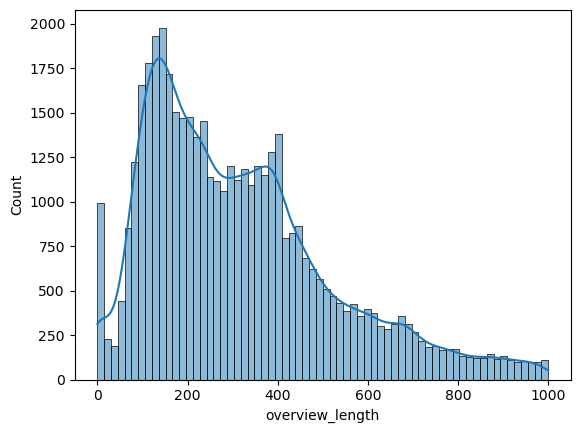

In [23]:
# . Text Length Analysis

df['overview_length'] = df['overview'].apply(len)
sns.histplot(df['overview_length'], kde=True)

In [24]:
# finding most common genre

from collections import Counter

all_genres = ", ".join(df['genres']).split(", ")
Counter(all_genres).most_common(10)

[("[{'id': 18", 11926),
 ("'name': 'Drama'}", 11057),
 ("'name': 'Drama'}]", 9141),
 ("[{'id': 35", 8792),
 ("{'id': 18", 8272),
 ("'name': 'Comedy'}", 7518),
 ("{'id': 53", 5951),
 ("'name': 'Action'}", 5719),
 ("'name': 'Comedy'}]", 5624),
 ("{'id': 10749", 5530)]

In [25]:
import ast  # Ye module string ko Python object me convert karne ke liye use hota hai.

def clean_genres(x):
    try:
        if isinstance(x, str) and x.startswith('['):   
            
            return " ".join([i['name'] for i in ast.literal_eval(x)])
        else:
            return ""
    except:
        return ""

df['genres'] = df['genres'].apply(clean_genres)

In [26]:
# finding most common genre after "Cleaning_genres"

from collections import Counter

all_genres = ", ".join(df['genres']).split(", ")
Counter(all_genres).most_common(10)

[('Drama', 4981),
 ('Comedy', 3609),
 ('Documentary', 2710),
 ('', 2434),
 ('Drama Romance', 1297),
 ('Comedy Drama', 1130),
 ('Horror', 971),
 ('Comedy Romance', 927),
 ('Comedy Drama Romance', 591),
 ('Drama Comedy', 530)]

In [27]:
df['tagline'] = df['tagline'].fillna('')

In [28]:
df['vote_average'] = df['vote_average'].fillna(0)  # This will fill na with (0) 

# df['vote_average'] = df['vote_average'].fillna(df['vote_average'].mean())  # This will fill na with (mean) values

In [29]:
df['tags'] = df['overview']+" "+ df['genres'] +" "+df['tagline']

In [30]:
df.head()

,title,overview,genres,tagline,vote_average,popularity,overview_length,tags
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,,7.7,21.946943,303,"Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,Roll the dice and unleash the excitement!,6.9,17.015539,395,When siblings Judy and Peter discover an encha...
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,Still Yelling. Still Fighting. Still Ready for...,6.5,11.712900,327,A family wedding reignites the ancient feud be...
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,Friends are the people who let you be yourself...,6.1,3.859495,270,"Cheated on, mistreated and stepped on, the wom..."
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,Just When His World Is Back To Normal... He's ...,5.7,8.387519,318,Just when George Banks has recovered from his ...


In [31]:
# Removing StopWords and Panctuation

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

In [32]:
# Downloading Stopwords and wordnet
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [33]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


In [34]:
# Text Preprocessing 

def preprocessing(text):
    # Lowercase
    text = str(text).lower()
     
    # Removing punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # spliting words 
    words = text.split()

    # Removing stopwords
    words = [word for word in words if word not in stop_words]

    # lemitizing 
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words) 

df['tags'] = df['tags'].apply(preprocessing)

In [35]:
df.head()

,title,overview,genres,tagline,vote_average,popularity,overview_length,tags
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,,7.7,21.946943,303,led woody andys toy live happily room andys bi...
1,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,Roll the dice and unleash the excitement!,6.9,17.015539,395,sibling judy peter discover enchanted board ga...
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,Still Yelling. Still Fighting. Still Ready for...,6.5,11.712900,327,family wedding reignites ancient feud nextdoor...
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,Friends are the people who let you be yourself...,6.1,3.859495,270,cheated mistreated stepped woman holding breat...
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,Just When His World Is Back To Normal... He's ...,5.7,8.387519,318,george bank recovered daughter wedding receive...


In [36]:
df = df.reset_index(drop = True)

In [37]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [38]:
indices.head()

title
Toy Story                      0
Jumanji                        1
Grumpier Old Men               2
Waiting to Exhale              3
Father of the Bride Part II    4
dtype: int64

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features = 50000, stop_words = "english")
tfidf

TfidfVectorizer(max_features=50000, stop_words='english')

In [40]:
tfidf_vector  = tfidf.fit_transform(df['tags'])

In [41]:
tfidf_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1280568 stored elements and shape (45316, 50000)>

In [42]:
from sklearn.metrics.pairwise import cosine_similarity

In [43]:
def recommend(title, n = 10):

    # Check if movie in dataSet
    if title not in indices:
        return ["Movie not found"]

    idx = indices[title]

    sim_score = cosine_similarity(tfidf_vector[idx], tfidf_vector).flatten()

    similar_idx = sim_score.argsort()[::-1][1:n+1]
    return df['title'].iloc[similar_idx]
    

In [44]:
recommend('Grumpier Old Men')

9191     An Extremely Goofy Movie
35467                         Max
9101             Wishful Thinking
233                 A Goofy Movie
841                  Gone Fishin'
4094                Heartbreakers
441                      Fearless
1613                         Bent
454                       Go Fish
2278                     Rushmore
Name: title, dtype: object

In [45]:
recommend('Toy Story')

2991                Toy Story 2
15317               Toy Story 3
24460                 Small Fry
6424     What's Up, Tiger Lily?
17152                 Group Sex
1068      Rebel Without a Cause
1196                  Manhattan
11378    For Your Consideration
483                      Malice
1928                  Condorman
Name: title, dtype: object